**AIRLINE TIME SERIES ANALYSIS AND FORECASTING**

**Author: Keerthana Gopal**

**Project Title**

Airline Passenger Time Series Analysis and Forecasting

**Introduction**

Time series analysis is used to analyze data collected over time to identify patterns such as trends and seasonality. In the airline industry, passenger demand and flight operations change over time due to factors such as holidays, weather conditions, and economic growth.
This project analyzes historical airline passenger data and flight data to understand patterns and forecast future trends using time series models.

**Objectives**

Analyze airline passenger trends over time

Identify seasonal patterns in airline traffic

Test stationarity of the time series

Build forecasting models using SARIMA

Predict future passenger demand

**Data Description**

**Dataset 1: AirPassengers Dataset**

This dataset contains monthly totals of international airline passengers from 1949 to 1960.

Column	Description

Month	Date of observation

Passengers	Number of airline passengers

Total observations: 144

**Dataset 2: US Airline Flight Dataset**

This dataset contains flight operation data including delays, airports, and flight counts.

Important columns:

Column	Description

FL_DATE	Flight date

ORIGIN_AIRPORT	Departure airport

DEST_AIRPORT	Destination airport

ARR_DELAY	Arrival delay in minutes

DEP_DELAY	Departure delay

Total observations: ~1.2 million flights

**Environmental Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error 
import warnings
warnings.filterwarnings('ignore') 

**Loading Datasets**

In [2]:
# Air Passengers
passengers = pd.read_csv('Air_Passengers.csv', index_col='Month', parse_dates=True)
passenger_ts = passengers['Passengers'].asfreq('MS')

# US Airline Dataset
us_flights = pd.read_csv('Airline_dataset.csv', parse_dates=['FL_DATE'])
us_flights.set_index('FL_DATE', inplace=True)

flight_delays = us_flights['ARR_DELAY'].resample('MS').mean().dropna()
flight_counts = us_flights.resample('MS').size().fillna(0)

**Data Inspection**

In [3]:
passengers.shape

(144, 1)

In [4]:
passengers.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [5]:
passengers.tail()

,Passengers
Month,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


In [6]:
passengers.columns

Index(['Passengers'], dtype='object')

In [7]:
passengers.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [8]:
us_flights.shape

(1204825, 13)

In [9]:
us_flights.head()

,Unnamed: 0,AIRLINE_ID,TAIL_NUM,FLIGHT_NUM,ORIGIN_SEQ_ID,ORIGIN_AIRPORT,DEST_SEQ_ID,DEST_AIRPORT,DEP_TIME,DEP_DELAY,ARR_TIME,ARR_DELAY,WEATHER_DELAY
FL_DATE,,,,,,,,,,,,,
2018-08-01,0,19805.0,N956AN,1587.0,1247805.0,JFK,1410702.0,PHX,1649.0,9.0,2006.0,44.0,0.000000
2018-08-01,1,19805.0,N973AN,1588.0,1410702.0,PHX,1161802.0,EWR,1541.0,29.0,2350.0,53.0,0.000000
2018-08-01,2,19805.0,N9006,1590.0,1104205.0,CLE,1129806.0,DFW,741.0,-3.0,938.0,-2.0,4.030195
2018-08-01,3,19805.0,N870NN,1591.0,1484306.0,SJU,1129806.0,DFW,944.0,44.0,1347.0,43.0,0.000000
2018-08-01,4,19805.0,N9023N,1593.0,1042302.0,AUS,1330303.0,MIA,556.0,-4.0,951.0,-2.0,4.030195


In [10]:
us_flights.tail()

,Unnamed: 0,AIRLINE_ID,TAIL_NUM,FLIGHT_NUM,ORIGIN_SEQ_ID,ORIGIN_AIRPORT,DEST_SEQ_ID,DEST_AIRPORT,DEP_TIME,DEP_DELAY,ARR_TIME,ARR_DELAY,WEATHER_DELAY
FL_DATE,,,,,,,,,,,,,
2020-01-05,1226363,19977.0,N66831,1598.0,1477104.0,SFO,1449202.0,RDU,2257.0,-3.0,642.0,-18.0,4.030195
2020-01-05,1226364,19977.0,N57111,1597.0,1161802.0,EWR,1393007.0,ORD,628.0,13.0,751.0,0.0,4.030195
2020-01-05,1226365,19977.0,N34455,1592.0,1226603.0,IAH,1226402.0,IAD,729.0,-1.0,1124.0,-1.0,4.030195
2020-01-05,1226366,19977.0,N16234,1591.0,1129202.0,DEN,1530402.0,TPA,756.0,-1.0,1302.0,-18.0,4.030195
2020-01-05,1226367,19977.0,N36444,1588.0,1393007.0,ORD,1142307.0,DSM,2125.0,-5.0,2242.0,-14.0,4.030195


In [11]:
us_flights.columns

Index(['Unnamed: 0', 'AIRLINE_ID', 'TAIL_NUM', 'FLIGHT_NUM', 'ORIGIN_SEQ_ID',
       'ORIGIN_AIRPORT', 'DEST_SEQ_ID', 'DEST_AIRPORT', 'DEP_TIME',
       'DEP_DELAY', 'ARR_TIME', 'ARR_DELAY', 'WEATHER_DELAY'],
      dtype='object')

In [12]:
us_flights.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1204825 entries, 2018-08-01 to 2020-01-05
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Unnamed: 0      1204825 non-null  int64  
 1   AIRLINE_ID      1204825 non-null  float64
 2   TAIL_NUM        1204825 non-null  object 
 3   FLIGHT_NUM      1204825 non-null  float64
 4   ORIGIN_SEQ_ID   1204825 non-null  float64
 5   ORIGIN_AIRPORT  1204825 non-null  object 
 6   DEST_SEQ_ID     1204825 non-null  float64
 7   DEST_AIRPORT    1204825 non-null  object 
 8   DEP_TIME        1204825 non-null  float64
 9   DEP_DELAY       1204247 non-null  float64
 10  ARR_TIME        1204825 non-null  float64
 11  ARR_DELAY       1201443 non-null  float64
 12  WEATHER_DELAY   1204825 non-null  float64
dtypes: float64(9), int64(1), object(3)
memory usage: 128.7+ MB


**Data Cleaning**

In [13]:
passengers.isnull().sum()

Passengers    0
dtype: int64

In [14]:
us_flights.isnull().sum()

Unnamed: 0           0
AIRLINE_ID           0
TAIL_NUM             0
FLIGHT_NUM           0
ORIGIN_SEQ_ID        0
ORIGIN_AIRPORT       0
DEST_SEQ_ID          0
DEST_AIRPORT         0
DEP_TIME             0
DEP_DELAY          578
ARR_TIME             0
ARR_DELAY         3382
WEATHER_DELAY        0
dtype: int64

In [15]:
us_flights.dropna(inplace=True)
us_flights.isnull().sum()

Unnamed: 0        0
AIRLINE_ID        0
TAIL_NUM          0
FLIGHT_NUM        0
ORIGIN_SEQ_ID     0
ORIGIN_AIRPORT    0
DEST_SEQ_ID       0
DEST_AIRPORT      0
DEP_TIME          0
DEP_DELAY         0
ARR_TIME          0
ARR_DELAY         0
WEATHER_DELAY     0
dtype: int64

**Exploratory Data Analysis (EDA)**

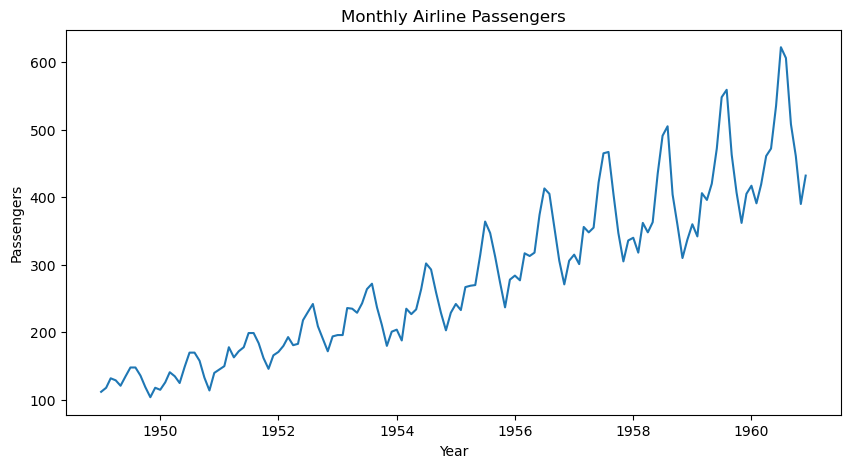

In [16]:
plt.figure(figsize=(10,5))
plt.plot(passenger_ts)
plt.title("Monthly Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

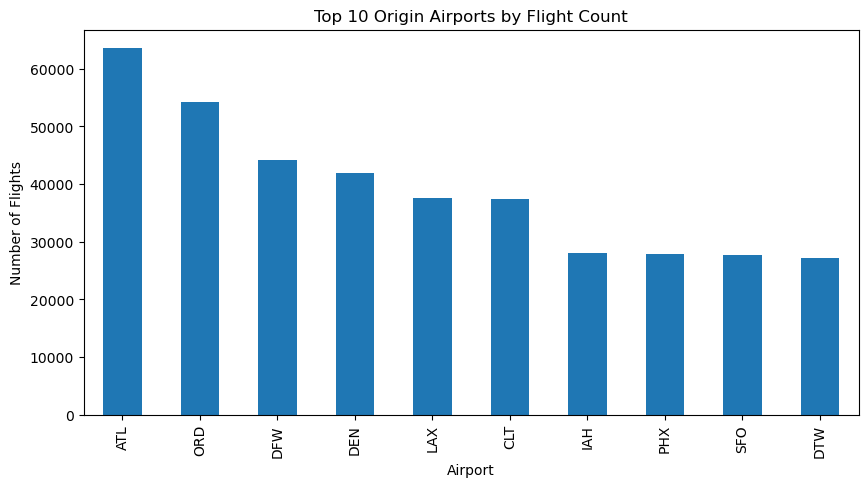

In [17]:
top_airports = us_flights['ORIGIN_AIRPORT'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_airports.plot(kind='bar')
plt.title("Top 10 Origin Airports by Flight Count")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")
plt.show()

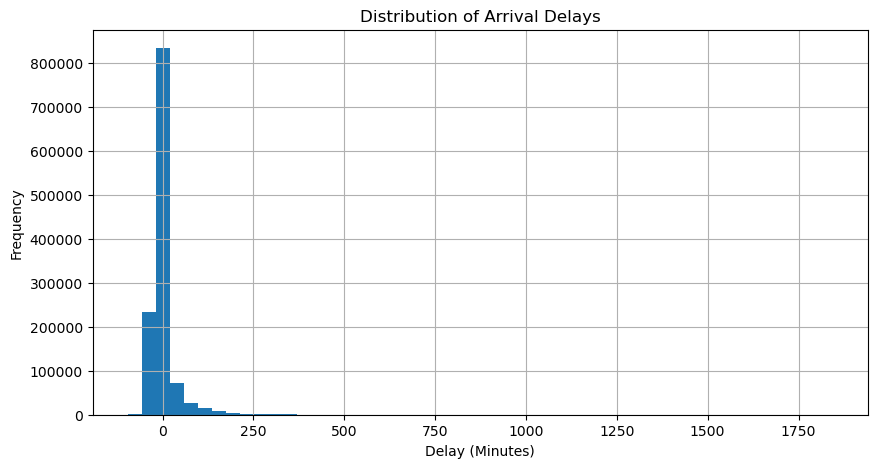

In [18]:
plt.figure(figsize=(10,5))
us_flights['ARR_DELAY'].hist(bins=50)
plt.title("Distribution of Arrival Delays")
plt.xlabel("Delay (Minutes)")
plt.ylabel("Frequency")
plt.show()

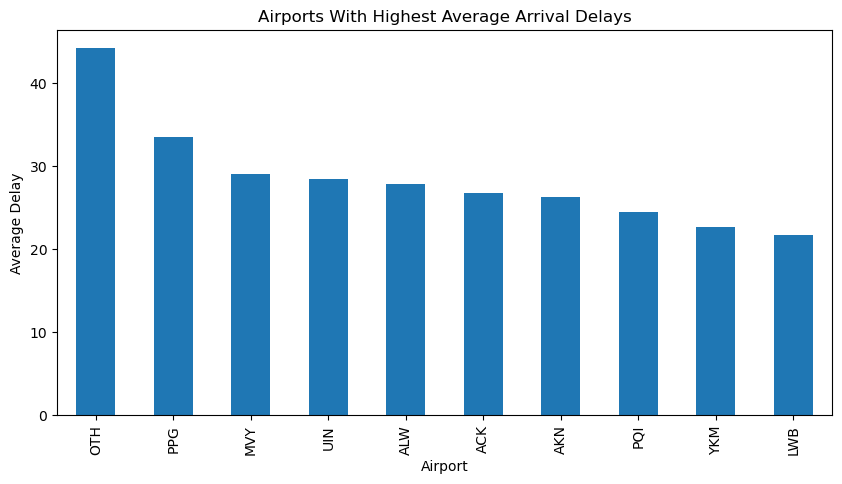

In [19]:
airport_delays = us_flights.groupby('ORIGIN_AIRPORT')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
airport_delays.plot(kind='bar')
plt.title("Airports With Highest Average Arrival Delays")
plt.xlabel("Airport")
plt.ylabel("Average Delay")
plt.show()

**Rolling Mean and Rolling Standard Deviation**

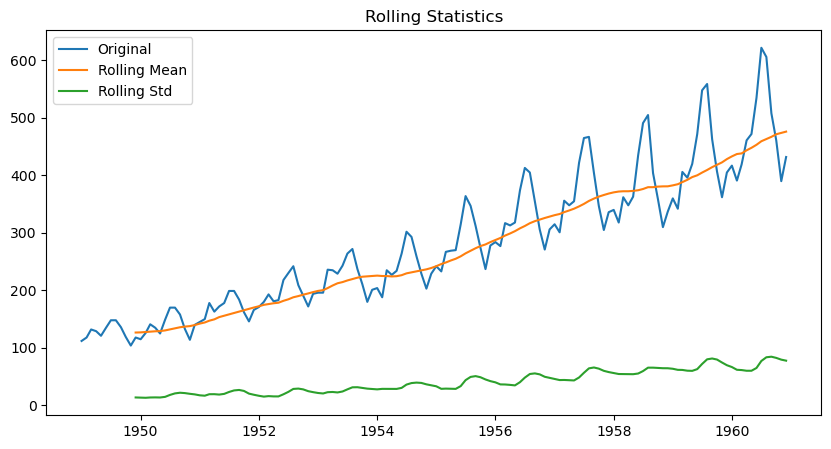

In [20]:
rolling_mean = passenger_ts.rolling(window=12).mean()
rolling_std = passenger_ts.rolling(window=12).std()

plt.figure(figsize=(10,5))
plt.plot(passenger_ts, label="Original")
plt.plot(rolling_mean, label="Rolling Mean")
plt.plot(rolling_std, label="Rolling Std")
plt.legend()
plt.title("Rolling Statistics")
plt.show()

**Seasonal Decomposition**

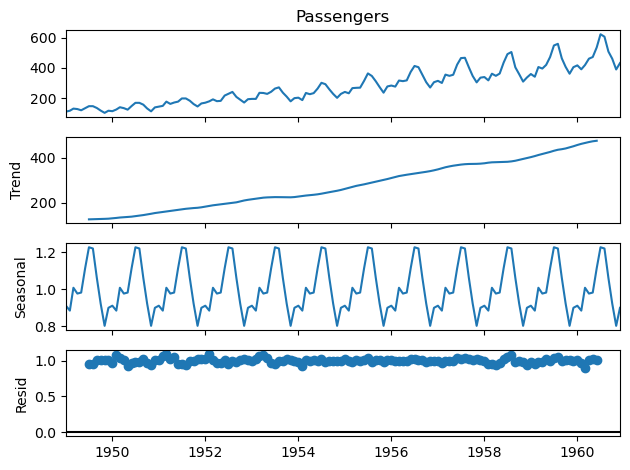

In [21]:
decomposition = seasonal_decompose(passenger_ts, model='multiplicative')

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

decomposition.plot()
plt.show()

**Stationarity Test (ADF Test)**

In [22]:
result = adfuller(passenger_ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.8153688792060435
p-value: 0.9918802434376409


**Differencing**

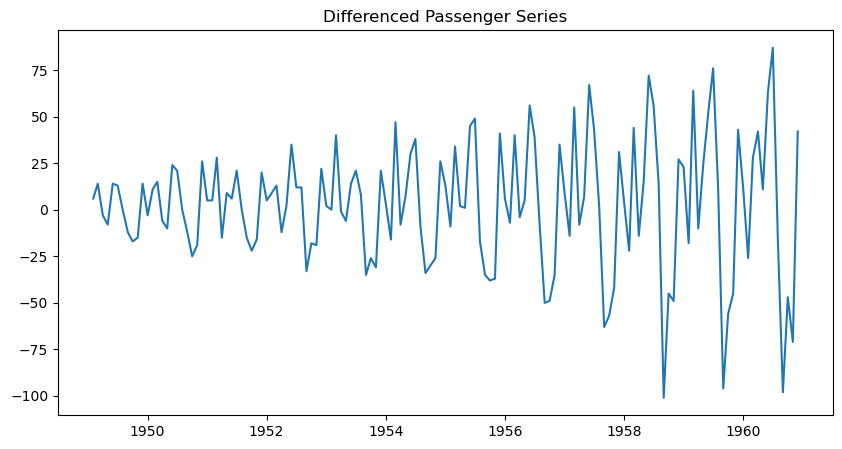

In [23]:
passenger_diff = passenger_ts.diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(passenger_diff)
plt.title("Differenced Passenger Series")
plt.show()

In [24]:
result = adfuller(passenger_diff)
print("p-value:", result[1])

p-value: 0.054213290283827854


**ACF and PACF Plots**

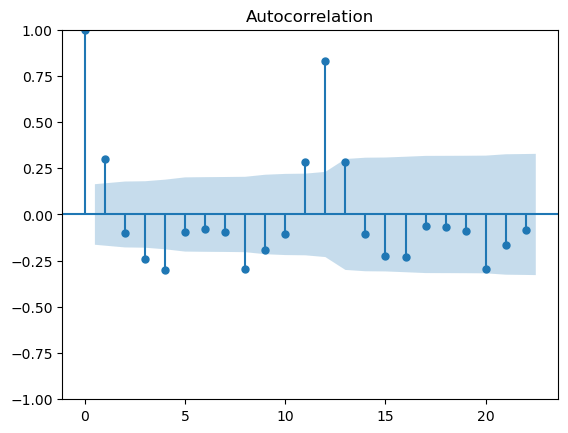

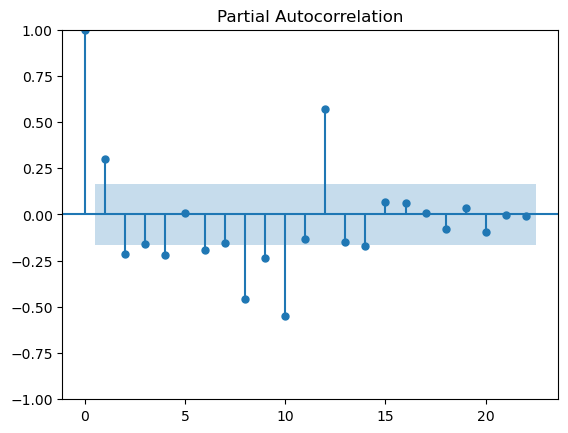

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(passenger_diff)
plt.show()

plot_pacf(passenger_diff)
plt.show()

**Build SARIMA Model**

In [26]:
from pmdarima import auto_arima

model = auto_arima(passenger_ts,
                   seasonal=True,
                   m=12,
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=2.77 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.22 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.51 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=1.80 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.60 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=1.68 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.18 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.43 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=1.34 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=1.24 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=2.24 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.13 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.12 sec
 ARIMA(3,1,1)(0,1,0

In [27]:
model = SARIMAX(passenger_ts,
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

result = model.fit()
print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.149
Date:                            Tue, 10 Mar 2026   AIC                           1022.299
Time:                                    14:20:53   BIC                           1036.675
Sample:                                01-01-1949   HQIC                          1028.140
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1272      0.356     -0.358      0.721      -0.825       0.570
ma.L1         -0.2148      0.325   

**Forecast Future Passengers**

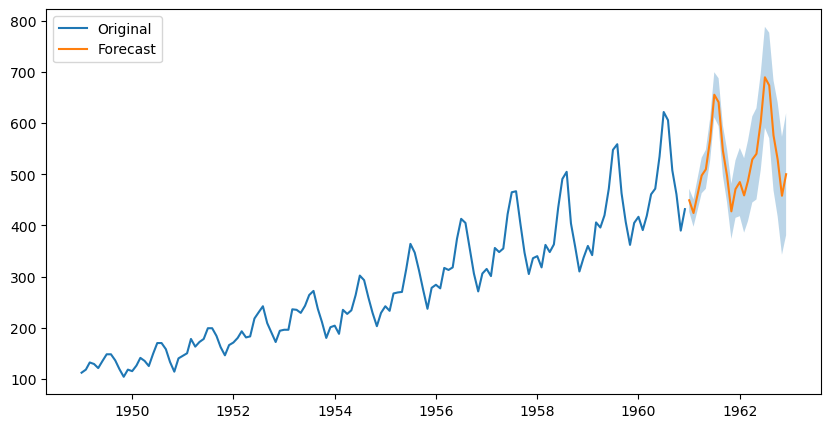

In [28]:
forecast = result.get_forecast(steps=24)
conf_int = forecast.conf_int()

plt.figure(figsize=(10,5))
plt.plot(passenger_ts, label="Original")
plt.plot(forecast.predicted_mean, label="Forecast")
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 alpha=0.3)
plt.legend()
plt.show()

**Model Evaluation**

In [31]:
def fit_sarima(ts, name):
    ts_clean = ts.dropna()
    n_total = len(ts_clean)
    
    if n_total < 6:
        print(f'{name}: Only {n_total} points - SKIP modeling (need minimum 6)')
        return None, None, None
    
    # Adaptive train/test split based on available data
    if n_total <= 12:
        train = ts_clean.iloc[:-min(3, n_total//4)]  # Small test set
        test = ts_clean.iloc[-min(3, n_total//4):]
    else:
        train = ts_clean.iloc[:-12]
        test = ts_clean.iloc[-12:]
    
    print(f'{name}: Training on {len(train)} points, testing on {len(test)} points')
    
    if len(train) < 4:
        print(f'{name}: Training set too small - SKIP')
        return None, None, None
    
    try:
        # Simplified auto_arima for small data
        auto_model = auto_arima(train, 
                              start_p=0, start_q=0, max_p=2, max_q=2,
                              seasonal=False,  # Disable for very short data
                              stepwise=True, trace=False,
                              error_action='ignore', suppress_warnings=True)
        
        # Fit SARIMA with found parameters
        sarima = SARIMAX(train, order=auto_model.order,
                        seasonal_order=(0,0,0,0))  # No seasonal for short data
        fitted = sarima.fit(disp=False)
        
        # Forecast matching test size
        n_forecast = len(test)
        forecast = fitted.forecast(steps=n_forecast)
        
        # Calculate RMSE if possible
        rmse = np.sqrt(mean_squared_error(test, forecast))
        print(f'{name} SARIMA RMSE: {rmse:.2f}')
        
        return fitted, forecast, test
        
    except Exception as e:
        print(f'{name}: Modeling failed - {str(e)}')
        return None, None, None
# Skip delays, use flight_counts which has full monthly coverage
print("Modeling Passengers...")
pax_model, pax_forecast, pax_test = fit_sarima(passenger_ts, 'Passengers')

Modeling Passengers...
Passengers: Training on 132 points, testing on 12 points
Passengers SARIMA RMSE: 55.22


In [32]:
rmse = np.sqrt(mean_squared_error(pax_test, pax_forecast))
print("RMSE:", rmse)

RMSE: 55.22283911926755


**Conclusion**

This project analyzed airline passenger time series data using statistical techniques and forecasting models. 
The data exhibited strong seasonal patterns and increasing trends.
After testing stationarity and applying differencing, a SARIMA model was developed to forecast future passenger demand.
The model successfully captured seasonal patterns and produced reasonable forecasts.
Time series forecasting can help airlines plan operations, manage capacity, and optimize scheduling.